<a href="https://colab.research.google.com/github/Sen4Tech/Binuskop/blob/main/Sentimen_Analysis_SVM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Step 0: Install library
!pip install Sastrawi tqdm scikit-learn pandas numpy matplotlib seaborn

In [19]:
# Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

In [4]:
# Install Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [7]:
# Upload file CSV
from google.colab import files
uploaded = files.upload()

Saving review_kai_access.csv to review_kai_access.csv


In [8]:
# Read The CSV
reviews_df = pd.read_csv("review_kai_access.csv")
reviews_df['content'] = reviews_df['content'].fillna("")

In [9]:
# Lihat beberapa data awal
print("Contoh data awal:")
display(reviews_df.head())
print("Informasi dataset:")
display(reviews_df.info())

Contoh data awal:


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b9c21ea2-7e9d-41cc-aa4b-98f1e6019544,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,6.11.2,2025-04-26 17:59:38,NaN,NaN,6.11.2
1,b0ead291-7ab5-4885-a623-864a4d6f7fd7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cepat dan mudah,5,0,6.11.2,2025-04-26 16:17:56,NaN,NaN,6.11.2
2,fe89a5e0-0087-4a68-9a3f-23a935fdec7c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,pelayanan memuaskan,5,0,6.11.2,2025-04-26 16:00:18,NaN,NaN,6.11.2
3,99d56a35-17b7-454e-9d69-2c9cdc9f8a8e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,the best,5,0,6.11.2,2025-04-26 14:40:46,NaN,NaN,6.11.2
4,5632ab0d-19f6-4a6a-867d-fd52397ce8b1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kekurangan tidak bisa refund lewat aplikasi,5,0,NaN,2025-04-26 14:26:18,NaN,NaN,NaN


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  8045 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          145 non-null    object
 9   repliedAt             145 non-null    object
 10  appVersion            8045 non-null   object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB


None

In [10]:
# Step 2: Preprocessing Teks
factory_stopwords = StopWordRemoverFactory()
stopwords = factory_stopwords.get_stop_words()
stemmer = StemmerFactory().create_stemmer()

In [70]:
normalization_dict = {
    'oke': 'oke', 'ok': 'oke', 'k': 'oke', 'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk',
    'tdk': 'tidak', 'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak', 'nggak': 'tidak',
    'gk': 'tidak', 'g': 'tidak', 'sk': 'suka', 'trs': 'terus', 'klo': 'kalau', 'kl': 'kalau',
    'bs': 'bisa', 'bgt': 'banget', 'byk': 'banyak', 'pd': 'pada', 'dr': 'dari', 'krn': 'karena',
    'karna': 'karena', 'hrs': 'harus', 'dlm': 'dalam', 'sgt': 'sangat', 'sngt': 'sangat',
    'bngt': 'banget', 'bgs': 'bagus', 'bgus': 'bagus', 'kyk': 'seperti', 'kyak': 'seperti',
    'kaya': 'seperti', 'ny': 'nya', 'yah': 'ya', 'lg': 'lagi', 'lbh': 'lebih', 'tp': 'tapi',
    'tpi': 'tapi', 'ttg': 'tentang', 'spy': 'supaya', 'dpt': 'dapat', 'dah': 'sudah',
    'udh': 'sudah', 'sdh': 'sudah', 'udah': 'sudah', 'aja': 'saja', 'aj': 'saja',
    'doang': 'saja', 'skrg': 'sekarang', 'skrang': 'sekarang', 'yng': 'yang', 'sy': 'saya',
    'sya': 'saya', 'aq': 'saya', 'aku': 'saya', 'gw': 'saya', 'gue': 'saya', 'gua': 'saya',
    'lu': 'kamu', 'elo': 'kamu', 'loe': 'kamu', 'km': 'kamu', 'kmu': 'kamu', 'smua': 'semua',
    'stiap': 'setiap', 'ampe': 'sampai', 'sampe': 'sampai', 'blm': 'belum', 'blom': 'belum',
    'belom': 'belum', 'msh': 'masih', 'mw': 'mau', 'pgn': 'ingin', 'pgen': 'ingin',
    'pengen': 'ingin', 'pingin': 'ingin', 'trima': 'terima', 'trimakasih': 'terimakasih',
    'makasih': 'terimakasih', 'thx': 'terimakasih', 'thanks': 'terimakasih', 'apps': 'aplikasi',
    'app': 'aplikasi','apk':'aplikasi', 'kurang': 'tidak', 'acess': 'access', 'acces':'access', 'eror':'error',
    'moantap':'mantap','mantapp':'mantap','mantappp':'mantap', 'mntap':'mantap', 'mantaf':'mantap', 'lemot':'lama', 'disono':'disitu', 'perasaanku':'perasaanku',
    'sekaliii':'sekali', 'gini':'begini', 'updet':'update','smg':'semoga','jum':'jumat', 'eroorrrr':'error', 'kereeen':'keren', 'burukkkk':'buruk', 'sumpaah':'sumpah',
    'gabisa':'tidak bisa','d download':'di unduh','download':'unduh','d':'di', 'sayaa':'saya','gaada':'tidak ada','gaaada':'tidakada','klau':'kalau','kalo':'kalau','abis':'habis',
    'hri':'hari','ilang':'hilang','cm':'cuma','bgtu':'begitu','costumer':'customer','gada':'tidak ada',

}

def normalize_text(text):
    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

def clean_text(text):
    try:
        if text is None:
            return ""
        text = str(text).lower()                              # Lowercase
        text = re.sub(r'\d+', '', text)                       # Remove angka
        text = re.sub(r'[^\w\s]', '', text)                   # Remove tanda baca
        text = re.sub(r'\s+', ' ', text)                      # Remove spasi ganda
        text = text.strip()                                   # Remove spasi depan belakang
        text = normalize_text(text)                           # Normalisasi kata
        text = ' '.join([word for word in text.split() if word not in stopwords])  # Remove stopwords
        text = stemmer.stem(text)                             # Stemming
        return text
    except Exception as e:
        return ""

custom_stopwords = [
    'nya','kai', 'access', 'kaiaccess',
]
stopwords.extend(custom_stopwords)

print("Sedang melakukan preprocessing teks...")
tqdm.pandas()
reviews_df['clean_text'] = reviews_df['content'].progress_apply(clean_text)

# Tampilkan contoh hasil preprocessing
print("\nHasil preprocessing:")
sample_df = pd.DataFrame({
    'Original': reviews_df['content'].head(10000),
    'Preprocessed': reviews_df['clean_text'].head(10000)
})
display(sample_df)

Sedang melakukan preprocessing teks...


100%|██████████| 10000/10000 [00:01<00:00, 7081.75it/s]



Hasil preprocessing:


,Original,Preprocessed
0,ok,oke
1,cepat dan mudah,cepat mudah
2,pelayanan memuaskan,layan muas
3,the best,the best
4,kekurangan tidak bisa refund lewat aplikasi,kurang refund lewat aplikasi
...,...,...
9995,Ini gak Boongkan Saya mau Pulang ke jakarta ha...,boongkan mau pulang jakarta hari kamis
9996,Gak helas eror,has error
9997,"Yth, PT. KAI Mohon sediakan ruang untuk kompla...",yth pt mohon sedia ruang komplain aplikasi jua...
9998,Memudahkan dan menyamankan,mudah nyaman


In [71]:
# Step 3: Labeling Sentimen Berdasarkan Komentar
def label_sentiment_by_rating(score):
    if score >= 4:
        return 'positive'
    elif score <= 2:
        return 'negative'
    else:
        return None

reviews_df['label'] = reviews_df['score'].apply(label_sentiment_by_rating)

# Filter hanya data dengan label positif atau negatif
filtered_reviews = reviews_df[reviews_df['label'].notna()].copy()
print("\nJumlah data setelah buang netral:", filtered_reviews.shape)

# Lihat distribusi label
label_counts = filtered_reviews['label'].value_counts()
print("\nDistribusi label:")
print(label_counts)


Jumlah data setelah buang netral: (9444, 13)

Distribusi label:
label
negative    5753
positive    3691
Name: count, dtype: int64


In [72]:
# Step 4: Split Data
X = filtered_reviews['clean_text']
y = filtered_reviews['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
# Step 5: TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_df=0.95, min_df=5, ngram_range=(1, 3))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Menampilkan hasil split
print("\n=== Data Split: Training dan Test ===")
print(f"Training Data (X_train): {X_train.shape[0]} samples")
print(f"Test Data (X_test): {X_test.shape[0]} samples")
print(f"Training Labels (y_train): {y_train.value_counts()}")
print(f"Test Labels (y_test): {y_test.value_counts()}")

# Tampilkan beberapa feature dari TF-IDF
print("\nContoh fitur TF-IDF (10000 fitur pertama):")
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:1000])


=== Data Split: Training dan Test ===
Training Data (X_train): 7555 samples
Test Data (X_test): 1889 samples
Training Labels (y_train): label
negative    4581
positive    2974
Name: count, dtype: int64
Test Labels (y_test): label
negative    1172
positive     717
Name: count, dtype: int64

Contoh fitur TF-IDF (10000 fitur pertama):
['ac' 'account' 'ad' 'ada' 'ada aplikasi' 'adain' 'adil' 'admin'
 'adminnya' 'adu' 'aduh' 'ae' 'ah' 'ajah' 'ajar' 'aju' 'akal' 'akhir'
 'akhir tiket' 'akses' 'akses mudah' 'akses tiket' 'aktif' 'aktifasi'
 'aktivasi' 'aktivasi kaipay' 'aktivasi pay' 'aktivitas' 'akun'
 'akun baru' 'akun basic' 'akun keluar' 'akun lama' 'akun malah'
 'akun sama' 'akun susah' 'akurat' 'alam' 'alami' 'alami kendala' 'alas'
 'alfamart' 'alhamdulillah' 'alhasil' 'alias' 'all' 'allah' 'already'
 'already exist' 'ama' 'aman' 'aman aman' 'aman nyaman' 'ambil' 'ampas'
 'ampun' 'an' 'anak' 'ancur' 'andai' 'andal' 'android' 'aneh'
 'aneh aplikasi' 'anggap' 'anggar' 'angka' 'angkut' 'a

In [74]:
# Step 6: Train Model SVM
print("\nMemulai training model SVM...")
model_svm = LinearSVC(
    C=1.0,
    max_iter=1000,
    tol=1e-4
)

model_svm.fit(X_train_tfidf, y_train)
print("Training selesai!")


Memulai training model SVM...
Training selesai!



Accuracy: 0.9025939650608787

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.92      0.93      0.92      1172
    positive       0.88      0.86      0.87       717

    accuracy                           0.90      1889
   macro avg       0.90      0.89      0.90      1889
weighted avg       0.90      0.90      0.90      1889


=== Confusion Matrix ===


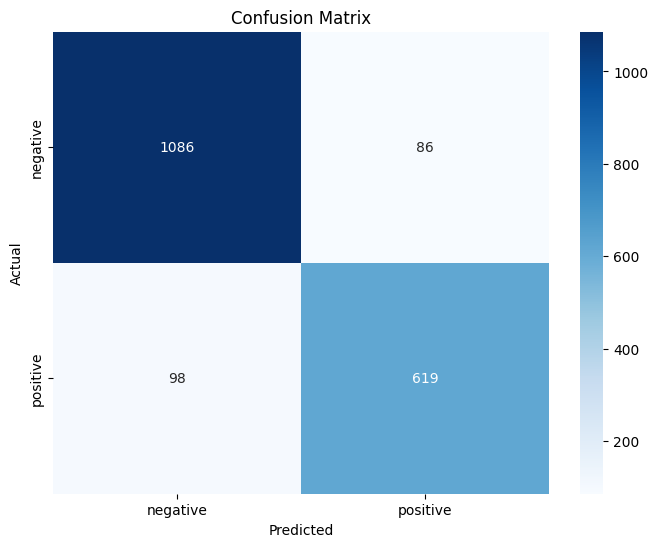

In [75]:
# Step 7: Evaluasi
y_pred = model_svm.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

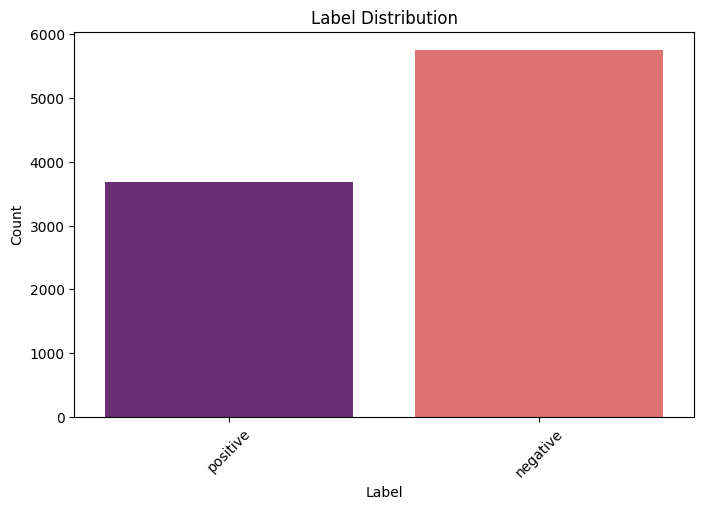

In [76]:
# Visualisasi Label Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', hue='label', data=filtered_reviews, palette='magma', legend=False)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

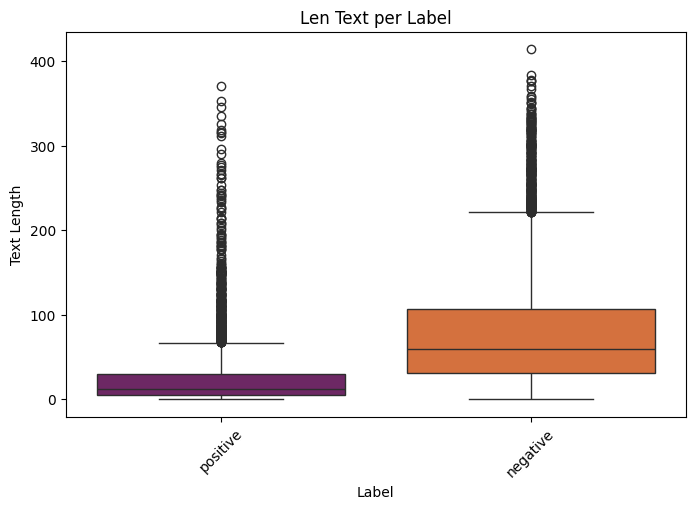

In [77]:
# Visualisasi Panjang Teks per Label
filtered_reviews['text_length'] = filtered_reviews['clean_text'].apply(len)
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='text_length', hue='label', data=filtered_reviews, palette='inferno', legend=False)
plt.title("Len Text per Label")
plt.xlabel("Label")
plt.ylabel("Text Length")
plt.xticks(rotation=45)
plt.show()

In [78]:
#Lihat kata-kata yang paling penting per kelas
def get_top_n_words(corpus, labels, tfidf_vec, class_label, n=10):
    # Dapatkan indeks dokumen dengan label tertentu
    idx = np.array(labels == class_label)

    # Ambil vektor TF-IDF untuk dokumen ini
    tfidf_matrix = tfidf_vec.transform(corpus[idx])

    # Penjumlahan fitur di semua dokumen
    feature_sum = np.array(tfidf_matrix.sum(axis=0)).flatten()

    # Dapatkan top words dengan nilai tertinggi
    top_idx = np.argsort(feature_sum)[-n:][::-1]
    top_words = {feature_names[i]: feature_sum[i] for i in top_idx}

    return top_words

# Dapatkan kata-kata teratas untuk setiap label
print("\n=== Top 20 Terms per Label ===")
vectorizer = TfidfVectorizer(max_df=0.95, min_df=5, ngram_range=(1, 3))
X_tfidf = vectorizer.fit_transform(X)
feature_names = vectorizer.get_feature_names_out()

top_pos = get_top_n_words(X, y, vectorizer, 'positive', 20)
top_neg = get_top_n_words(X, y, vectorizer, 'negative', 20)

print("\nTop positive terms:")
for word, score in top_pos.items():
    print(f"{word}: {score:.4f}")

print("\nTop negative terms:")
for word, score in top_neg.items():
    print(f"{word}: {score:.4f}")


=== Top 20 Terms per Label ===

Top positive terms:
oke: 313.2910
bagus: 277.5589
mantap: 208.6156
sangat: 200.7677
bantu: 171.3224
mudah: 150.0627
baik: 146.6891
good: 140.4507
sangat bantu: 137.3673
keren: 68.9875
aplikasi: 60.4404
layan: 59.5459
cepat: 55.9645
tiket: 52.5167
lebih: 49.9664
nyaman: 47.5532
kereta: 45.4178
top: 37.4725
terimakasih: 36.7249
makin: 35.9929

Top negative terms:
aplikasi: 336.5156
tiket: 237.7314
lama: 142.3954
update: 138.5230
bayar: 129.3342
malah: 128.9871
mau: 128.7068
error: 123.6296
terus: 107.0734
masuk: 99.3424
susah: 98.0282
beli: 87.6762
baik: 87.5459
saldo: 82.2096
makin: 79.6958
antri: 79.0079
jelas: 78.4619
buat: 77.4569
padahal: 75.7188
jam: 74.9653


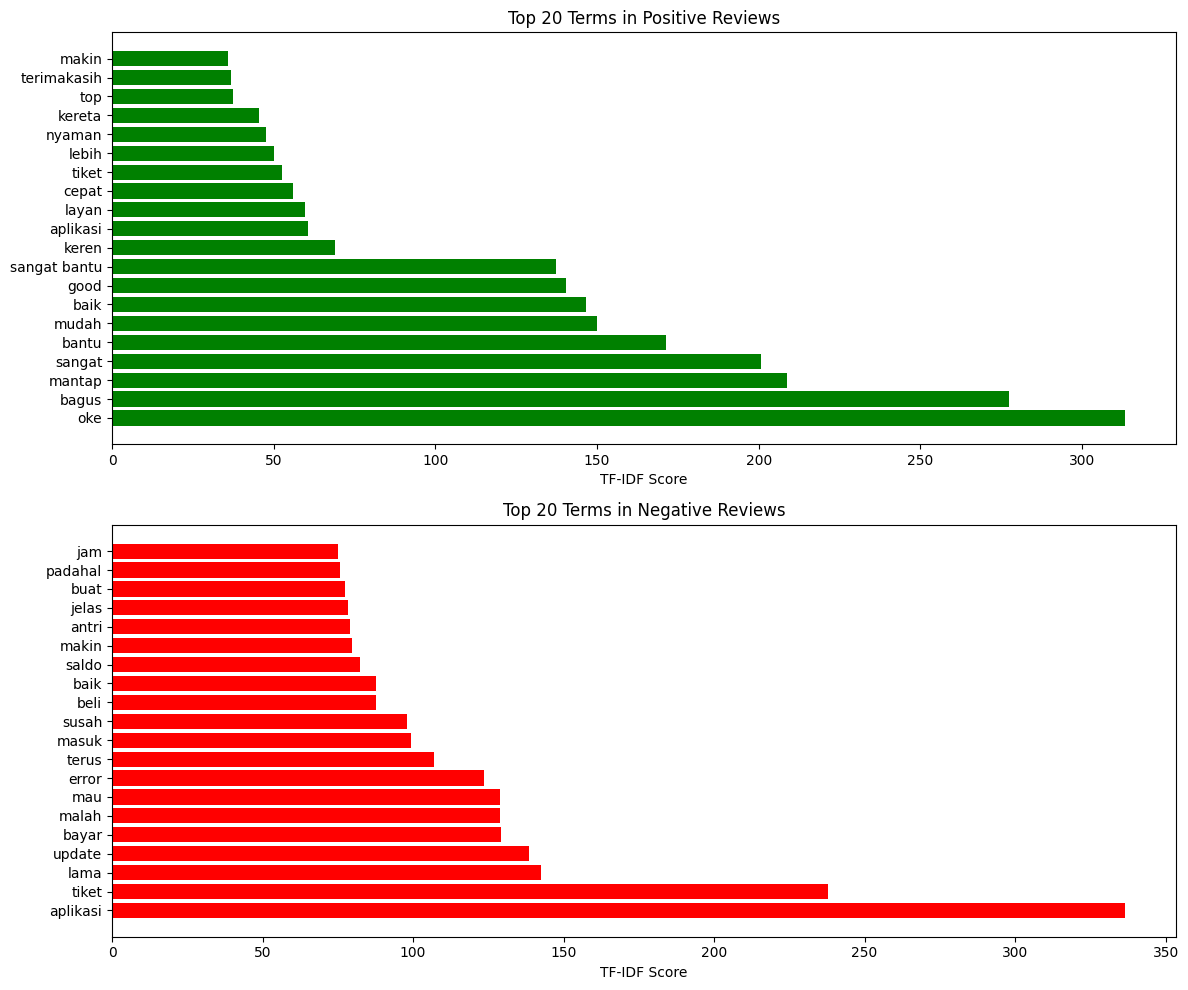

In [79]:
# Visualisasi top terms
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.barh(list(top_pos.keys()), list(top_pos.values()), color='green')
plt.title('Top 20 Terms in Positive Reviews')
plt.xlabel('TF-IDF Score')

plt.subplot(2, 1, 2)
plt.barh(list(top_neg.keys()), list(top_neg.values()), color='red')
plt.title('Top 20 Terms in Negative Reviews')
plt.xlabel('TF-IDF Score')

plt.tight_layout()
plt.show()